In [2]:
pip install cmsisdsp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 39.2 MB/s eta 0:00:00


In [17]:
import cmsisdsp as dsp
import cmsisdsp.fixedpoint as fix
import cmsisdsp.datatype as dt
import numpy as np
import scipy.signal as s
import librosa
from IPython import display as ipd
import matplotlib.pyplot as plt

Down sampling audio recordings to 800Hz

In [4]:
y, sr = librosa.load('Hemaris_fuciformis_C0001_HEMARI_0001_03jun2021-u-1.wav', sr=800)

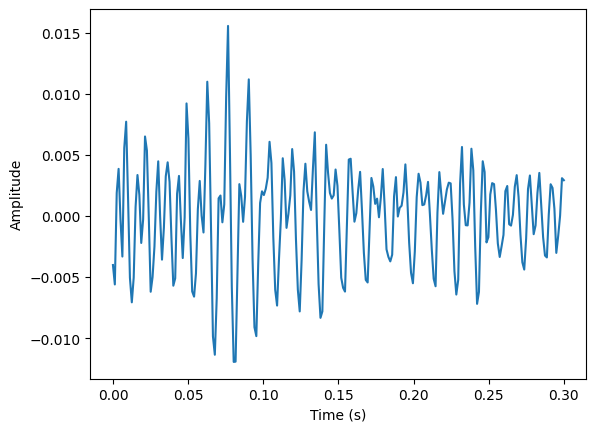

240


In [18]:
t = np.linspace(0, len(y)/sr, len(y))
plt.plot(t, y)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()
print(len(y))

ipd.Audio(y, rate=sr)

# FFT on speech sample using CMSIS-DSP

In [32]:
def frames_maker(signal, frame_length, sr, hop_size):
  frames = []
  num_frames = (len(signal) - frame_length) // hop_size + 1
  hamming_window = np.hamming(frame_length)
  hamming_Q15 = fix.toQ15(hamming_window)

  # Create FFT instance
  fft_instance = dsp.arm_rfft_instance_q15()

  # Create frames
  for c in range(num_frames):
    start = c * hop_size
    end = start + frame_length
    frame = signal[start:end]

    ## I would store this from the start

    frame_windowed = dsp.arm_mult_q15(frame, hamming_Q15)

    # Intilise fft using forward process aswell as bit reversal
    status = dsp.arm_rfft_init_q15(fft_instance, frame_length, 0, 1)
    # Create output buffer


    # Applying fft
    frames.append(dsp.arm_rfft_q15(fft_instance, frame_windowed))
  return frames


In [33]:
signalQ15 = fix.toQ15(y)
windows = frames_maker(signalQ15, 128, sr, 64) # Should create two frames


For this instance as the signal is a weird length I lose some data but on the tag I would use the whole signal when windowing

# Inversing and using overlap add


In [34]:
def reversing_frames(frames, frame_length, sr, hop_size):
  reconstructed_signal = np.zeros(len(frames) * hop_size + frame_length, dtype=np.int16)

  # fft isntance
  fft_instance = dsp.arm_rfft_instance_q15()

  for i, frame in enumerate(frames):
    #Initilise fft
    status = dsp.arm_rfft_init_q15(fft_instance, frame_length, 1, 1)
    inverse_frame = dsp.arm_rfft_q15(fft_instance, frame)

    start = i * hop_size
    end = start + frame_length
    reconstructed_signal[start:end] += inverse_frame
  return reconstructed_signal



In [38]:
reconstructed_signal = reversing_frames(windows, 128, sr, 64)

reconstructed_signalf15 = fix.Q15toF32(reconstructed_signal)


[-10  -8  -4  -6  -6  -4  -4  -4  -2  -2  -2  -2  -2  -4   0  -4  -2  -2
  -2  -2  -2  -4  -2  -2   0  -4  -4  -2  -4  -4  -2  -4   0   0   2   0
   0  -2   0   0   0   0  -4   0   2   0   2  -2   0   0   2   0   0  -4
  -4  -2   0   0   0   0   4   4   2  -4  -2  -4   0   2   2   0   0   0
   2   2  -2  -2  -2   0   0   0   2  -2  -2   2   2   0  -2  -2   0   0
   0   2   0   0   2   0   0   0  -2   0   0   2   0   0   0   0   0   0
  -2   0  -2  -2   0   0  -2   0   0   0   0  -2   0   0  -4   0  -4   0
  -2   0]
[-10  -8  -6  -6  -4  -6  -4  -4   0  -4  -2  -4  -4  -4  -2  -4   0  -2
  -4  -2  -2  -4  -4  -2  -2  -2  -2  -2  -4  -2  -2  -2   0   0   0  -2
   0   0   0  -2   2   0   2   0  -2  -2   0  -4   0   0   2  -2   0  -2
   2   0   2  -2   0  -2  -2   2   2  -4  -2   0   2   2   0  -2   0  -4
   0   0  -2   0   0   0   2   0   0  -2   0   2  -2   0   0   2   2   2
   2   2   0  -2   2  -2   0   0   0   2   0   0   0   2  -2   0  -2   0
  -2   2   0   0   0   0  -2   2   0  -2 

Text(0, 0.5, 'Amplitude')

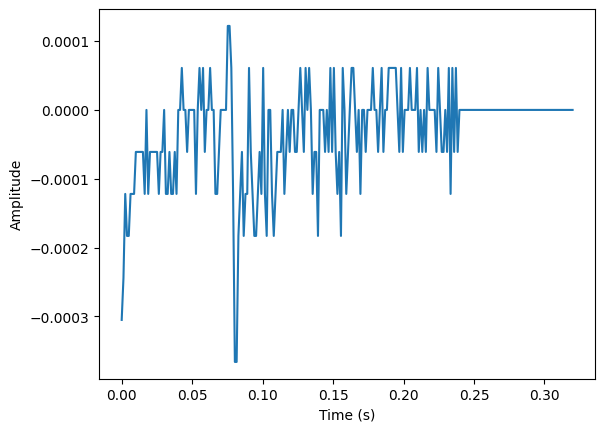

In [36]:
t = np.linspace(0, len(reconstructed_signalf15)/sr, len(reconstructed_signalf15))
plt.plot(t, reconstructed_signalf15)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

# DWT proccess on same signal
